In [121]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

train_path = "../data/split/train/train.csv"
test_path  = "../data/split/test/test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

df_train["price_per_m2"] = df_train["price"] / df_train["area"]
df_test["price_per_m2"]  = df_test["price"]  / df_test["area"]

kmeans = KMeans(n_clusters=3, random_state=42)
df_train["cluster"] = kmeans.fit_predict(df_train[["price_per_m2"]])

df_test["cluster"] = kmeans.predict(df_test[["price_per_m2"]])

cluster_0_train = df_train[df_train["cluster"] == 0]
cluster_1_train = df_train[df_train["cluster"] == 1]
cluster_2_train = df_train[df_train["cluster"] == 2]

cluster_0_test = df_test[df_test["cluster"] == 0]
cluster_1_test = df_test[df_test["cluster"] == 1]
cluster_2_test = df_test[df_test["cluster"] == 2]

print("Số lượng mỗi cluster (train):")
print(df_train["cluster"].value_counts())

print("\nSố lượng mỗi cluster (test):")
print(df_test["cluster"].value_counts())

Số lượng mỗi cluster (train):
cluster
1    1014
0     492
2      94
Name: count, dtype: int64

Số lượng mỗi cluster (test):
cluster
1    259
0    118
2     24
Name: count, dtype: int64


In [ ]:
# Mapping địa chỉ -> cluster (mode)
address_cluster_map = (
    df_train.groupby('address')['cluster']
        .agg(lambda s: s.mode().iat[0] if not s.mode().empty else -1)
        .reset_index()
        .rename(columns={'cluster':'cluster_mode'})
)
print('\n=== Địa chỉ thuộc cluster nào (mode) ===')
print(address_cluster_map)

# Lưu mapping để dùng lại ở model.ipynb
import os
save_dir = os.path.join("..", "model", "model6")
os.makedirs(save_dir, exist_ok=True)
map_path = os.path.join(save_dir, "address_cluster_map.csv")
address_cluster_map.to_csv(map_path, index=False)
print(f"Đã lưu mapping: {map_path}")


=== Địa chỉ thuộc cluster nào (mode) ===
       address  cluster_mode
0   bình chánh             1
1   bình thạnh             0
2     bình tân             1
3      cần giờ             0
4       gò vấp             1
5       nhà bè             1
6    phú nhuận             1
7       quận 1             0
8      quận 10             1
9      quận 11             2
10     quận 12             1
11      quận 2             0
12      quận 3             1
13      quận 4             1
14      quận 5             1
15      quận 6             1
16      quận 7             1
17      quận 8             1
18      quận 9             1
19     thủ đức             1
20    tân bình             0
21     tân phú             1


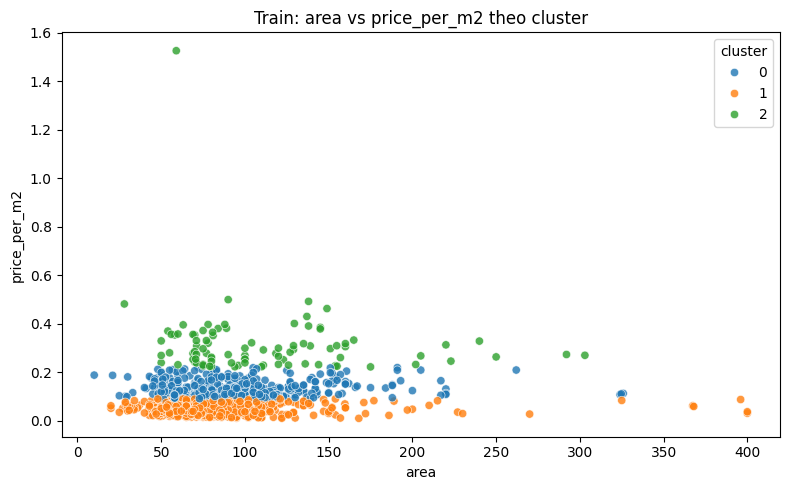

C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_22828\3577177283.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10')


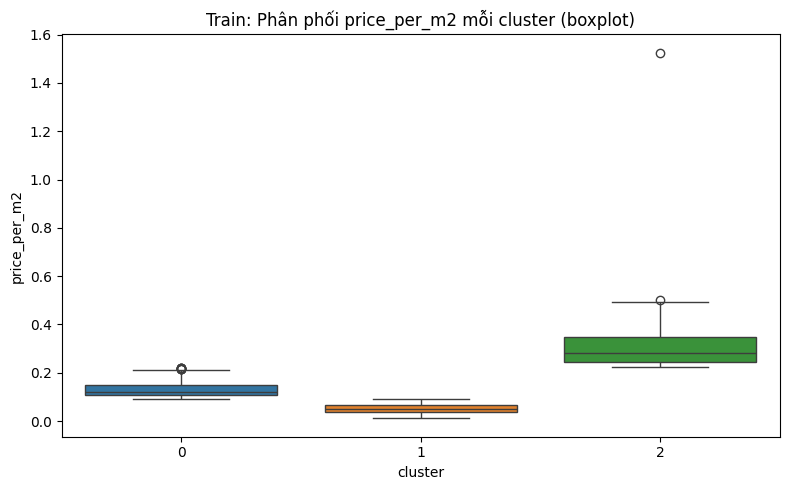

C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_22828\3577177283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10', cut=0)


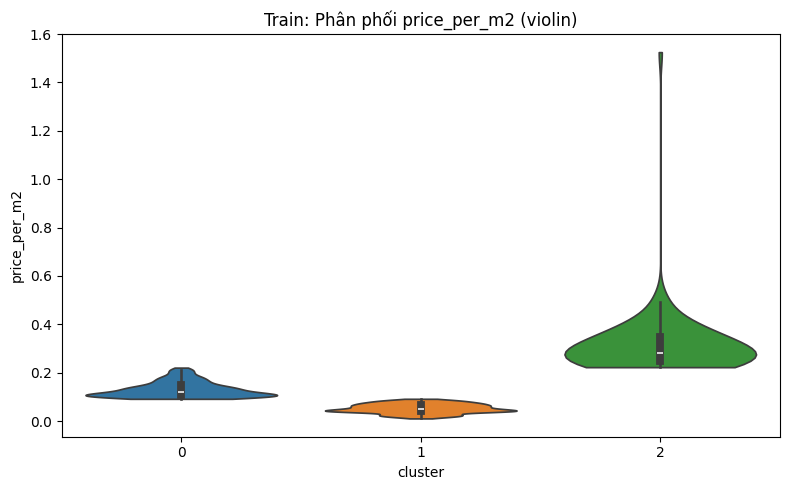

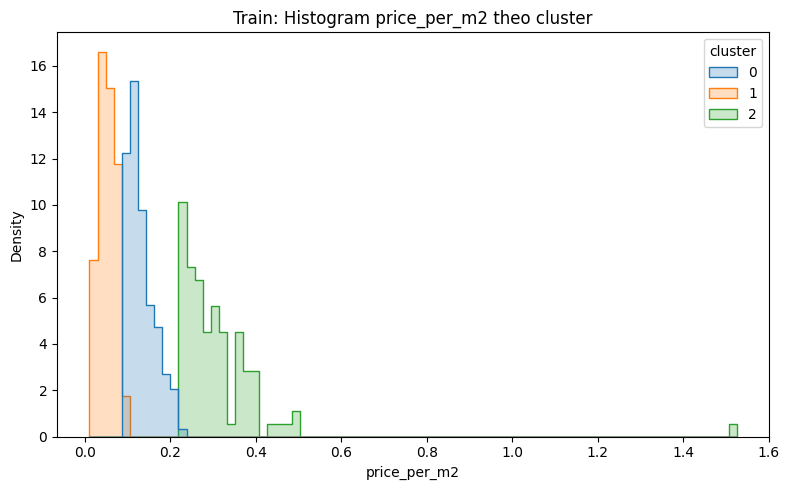


Tóm tắt price_per_m2 theo cluster:
         count      mean    median       min       max
cluster                                               
0          492  0.131255  0.121703  0.091957  0.220833
1         1014  0.052689  0.051379  0.010863  0.091912
2           94  0.313337  0.282187  0.222857  1.525424


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize clusters theo price_per_m2 (train)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_train, x='area', y='price_per_m2', hue='cluster', palette='tab10', alpha=0.8)
plt.title('Train: area vs price_per_m2 theo cluster')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10')
plt.title('Train: Phân phối price_per_m2 mỗi cluster (boxplot)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10', cut=0)
plt.title('Train: Phân phối price_per_m2 (violin)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df_train, x='price_per_m2', hue='cluster', element='step', stat='density', common_norm=False, palette='tab10')
plt.title('Train: Histogram price_per_m2 theo cluster')
plt.tight_layout()
plt.show()

cluster_stats = df_train.groupby('cluster')['price_per_m2'].agg(['count','mean','median','min','max']).sort_index()
print('\nTóm tắt price_per_m2 theo cluster:')
print(cluster_stats)


In [124]:
from sklearn.preprocessing import StandardScaler
for df in (df_train, df_test):
    drop_cols = [c for c in ['address','region'] if c in df.columns]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)


In [125]:
import torch

def build_dataset(df):
    feature_cols = ["area", "bedrooms"]
    X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[["price"]].values, dtype=torch.float32)
    return X, y

X0_train, y0_train = build_dataset(cluster_0_train)
X1_train, y1_train = build_dataset(cluster_1_train)
X2_train, y2_train = build_dataset(cluster_2_train)

X0_test, y0_test = build_dataset(cluster_0_test)
X1_test, y1_test = build_dataset(cluster_1_test)
X2_test, y2_test = build_dataset(cluster_2_test)

In [126]:
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error

def train_cluster_model(X_train, y_train, epochs=10000, lr=1e-3):
    model = nn.Linear(X_train.shape[1], 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for ep in range(epochs):
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (ep%1000==0):
            print(f"Epoch {ep+1}/{epochs} - Loss: {loss.item():.4f}")
    
    return model


def evaluate_cluster_model(model, X_test, y_test):
    with torch.no_grad():
        y_pred = model(X_test).cpu().numpy()

    y_true = y_test.cpu().numpy()

    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return r2, rmse



In [127]:
models = {}
import os

# Directory to save weights
save_dir = os.path.join("..", "model", "model6")
os.makedirs(save_dir, exist_ok=True)

for idx, (Xt_tr, Yt_tr, Xt_te, Yt_te) in enumerate([
    (X0_train, y0_train, X0_test, y0_test),
    (X1_train, y1_train, X1_test, y1_test),
    (X2_train, y2_train, X2_test, y2_test)
]):
    
    print(f"\n=== TRAINING CLUSTER {idx} ===")
    model = train_cluster_model(Xt_tr, Yt_tr)
    
    r2, rmse = evaluate_cluster_model(model, Xt_te, Yt_te)
    models[idx] = model
    
    # Save weights for this cluster
    weight_path = os.path.join(save_dir, f"cluster_{idx}.pt")
    torch.save(model.state_dict(), weight_path)
    print(f"Saved weights to: {weight_path}")
    
    print(f"Cluster {idx}: R² = {r2:.4f} | RMSE = {rmse:.4f}")


=== TRAINING CLUSTER 0 ===
Epoch 1/10000 - Loss: 91.9068
Epoch 1001/10000 - Loss: 11.1482
Epoch 1001/10000 - Loss: 11.1482
Epoch 2001/10000 - Loss: 11.0973
Epoch 2001/10000 - Loss: 11.0973
Epoch 3001/10000 - Loss: 11.0450
Epoch 3001/10000 - Loss: 11.0450
Epoch 4001/10000 - Loss: 11.0008
Epoch 4001/10000 - Loss: 11.0008
Epoch 5001/10000 - Loss: 10.9748
Epoch 5001/10000 - Loss: 10.9748
Epoch 6001/10000 - Loss: 10.9662
Epoch 6001/10000 - Loss: 10.9662
Epoch 7001/10000 - Loss: 10.9651
Epoch 7001/10000 - Loss: 10.9651
Epoch 8001/10000 - Loss: 10.9650
Epoch 8001/10000 - Loss: 10.9650
Epoch 9001/10000 - Loss: 10.9650
Epoch 9001/10000 - Loss: 10.9650
Saved weights to: ..\model\model6\cluster_0.pt
Cluster 0: R² = 0.7915 | RMSE = 3.7463

=== TRAINING CLUSTER 1 ===
Epoch 1/10000 - Loss: 57.0722
Saved weights to: ..\model\model6\cluster_0.pt
Cluster 0: R² = 0.7915 | RMSE = 3.7463

=== TRAINING CLUSTER 1 ===
Epoch 1/10000 - Loss: 57.0722
Epoch 1001/10000 - Loss: 3.5124
Epoch 1001/10000 - Loss: 3.5